# FYS-STK4155 Project 3

Before running the notebook, set DATA_DIR in the first cell to point to your local dataset folder.

Below the code for K-means clustering, PCA, and necessary preprocessing.

**NOTE:** to run grid search for PCA features, change RUN_GRID_SEARCH to True

To start, download the dataset and unzip it to a folder named data/ in the Project3 directory. Here is the link: https://drive.google.com/file/d/1Z8IdHF6iOaJ5Ju3LMlaQQGKq4GCqc79b/view?usp=sharing

Contains resampled cells size 32x32x3
Split:

80% train:
    416 dead
    - 1131 live

10% dev:
    52 dead
    - 141 live

10% test:
    52 dead
    - 142 live

In [ ]:
# Streamline imports and data loading via p3_module
import os
import time
from itertools import product

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from p3_module import (
    CNN,
    best_flip,
    eval_dev_metrics,
    extract_cell_features,
    fit_kmeans,
    fit_pca,
    fit_pca_v2,
    load_split,
    pca_kmeans_predict,
    pca_kmeans_predict_v2,
    plot_confusion,
    prepare_dataloaders,
    set_seed,
    train_cnn,
)

# Set data dir and seed
DATA_DIR = r"../data/cells"
SEED = 42
set_seed(SEED)

# Load splits
X_train, y_train = load_split(DATA_DIR, "train")
X_dev, y_dev     = load_split(DATA_DIR, "dev")
X_test, y_test   = load_split(DATA_DIR, "test")
print("Loaded shapes:", X_train.shape, X_dev.shape, X_test.shape)

### Inspec the dataset for sanity

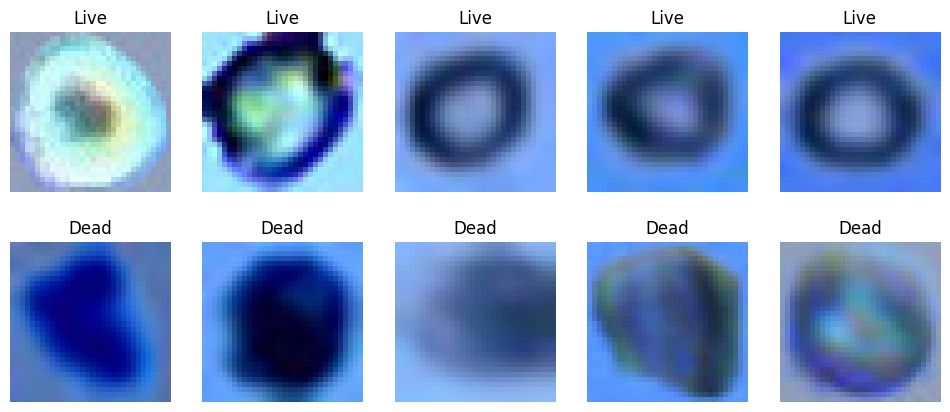

In [ ]:
# Display some examples of the live class and dead class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(X_train[y_train == 0][i])
    axes[0, i].set_title("Live")
    axes[0, i].axis('off')
    axes[1, i].imshow(X_train[y_train == 1][i])
    axes[1, i].set_title("Dead")
    axes[1, i].axis('off')
plt.show()


In [ ]:
# Quick verification: per-split class counts (0=live, 1=dead)
def _counts(y):
    return {0: int(np.sum(y == 0)), 1: int(np.sum(y == 1))}
print("Train counts:", _counts(y_train))
print("Dev counts:", _counts(y_dev))
print("Test counts:", _counts(y_test))

Train counts: {0: 1131, 1: 416}
Dev counts: {0: 141, 1: 52}
Test counts: {0: 142, 1: 52}


### Variance sweep
Sweeep explained variance over various PCA dimensions.

In [ ]:
# PCA variance sweep (raw RGB pixels)
components = [2, 5, 10, 15, 20, 50]
explained_variances = []

for m in components:
    pca_rgb, _ = fit_pca(X_train, n_components=m)
    e_vr = pca_rgb.explained_variance_ratio_.sum()
    explained_variances.append(e_vr)
    print(f"RGB PCA | m={m:2d} | EVR={e_vr:.4f}")

# PCA grayscale, [0,1]-scaled variance sweep
explained_variances_v2 = []

for m in components:
    pca_gray, _ = fit_pca_v2(X_train, n_components=m)
    e_vr_v2 = pca_gray.explained_variance_ratio_.sum()
    explained_variances_v2.append(e_vr_v2)
    print(f"Gray PCA | m={m:2d} | EVR={e_vr_v2:.4f}")


RGB PCA | m= 2 | EVR=0.4956
RGB PCA | m= 5 | EVR=0.7028
RGB PCA | m=10 | EVR=0.8322
RGB PCA | m=15 | EVR=0.8752
RGB PCA | m=20 | EVR=0.9039
RGB PCA | m=50 | EVR=0.9579
Gray PCA | m= 2 | EVR=0.6184
Gray PCA | m= 5 | EVR=0.8016
Gray PCA | m=10 | EVR=0.9039
Gray PCA | m=15 | EVR=0.9420
Gray PCA | m=20 | EVR=0.9582
Gray PCA | m=50 | EVR=0.9886


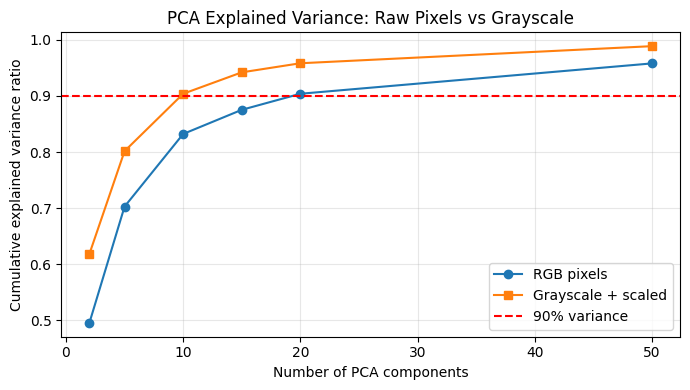

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(components, explained_variances, marker='o', label='RGB pixels')
plt.plot(components, explained_variances_v2, marker='s', label='Grayscale + scaled')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')

plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance ratio')
plt.title('PCA Explained Variance: Raw Pixels vs Grayscale')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
results = []

for m in components:
    print(f"\n PCA + KMeans, m={m}")

    # Fit PCA on train
    pca, X_train_pca = fit_pca_v2(X_train, n_components=m)

    # Fit k-means
    kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=20)
    kmeans.fit(X_train_pca)

    # Predict on dev
    y_dev_pred = pca_kmeans_predict_v2(X_dev, pca, kmeans, invert_labels=True)

    # Compute metrics
    f1  = f1_score(y_dev, y_dev_pred)
    acc = accuracy_score(y_dev, y_dev_pred)
    roc_auc = roc_auc_score(y_dev, y_dev_pred)

    results.append((m, f1, acc))
    print(f"F1={f1:.4f}, Acc={acc:.4f}")


 PCA + KMeans, m=2
F1=0.4175, Acc=0.3782

 PCA + KMeans, m=5
F1=0.4251, Acc=0.3834

 PCA + KMeans, m=10
F1=0.2174, Acc=0.6269

 PCA + KMeans, m=15
F1=0.4098, Acc=0.3731

 PCA + KMeans, m=20
F1=0.4098, Acc=0.3731

 PCA + KMeans, m=50
F1=0.4098, Acc=0.3731


## Preprocessing with PCA
We use 3 components for visualization purposes. Current PCA + Kmeans fails either way (for report):

High explained variance does not imply separability

KMeans collapses into 1 cluster - class imbalance


Shape of PCA transformed data: (1547, 3)


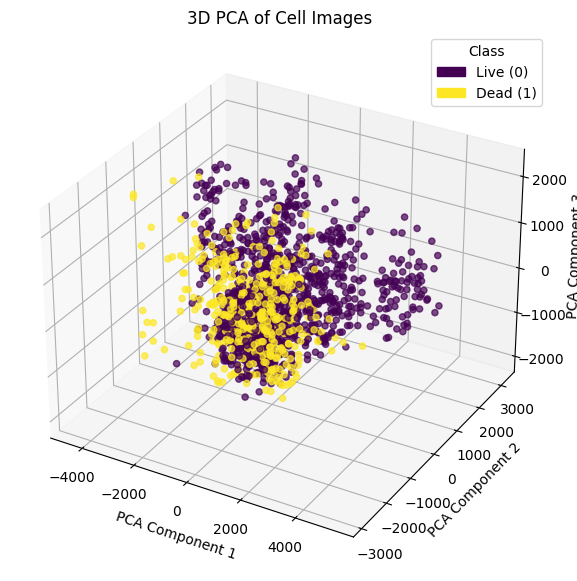

In [ ]:
# PCA via module helper
pca_pixels, X_train_pca = fit_pca(X_train, n_components=3)
print(f"Shape of PCA transformed data: {X_train_pca.shape}")


# 3D plot of PCA components
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_train, cmap='viridis', alpha=0.7)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('3D PCA of Cell Images')

cmap = plt.cm.viridis
live_patch = mpl.patches.Patch(color=cmap(0.0), label='Live (0)')
dead_patch = mpl.patches.Patch(color=cmap(1.0), label='Dead (1)')
ax.legend(handles=[live_patch, dead_patch], title='Class', loc='best')

plt.show()

## K-Means clustering

c:\Users\theod\miniconda3\envs\fys-stk4155\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


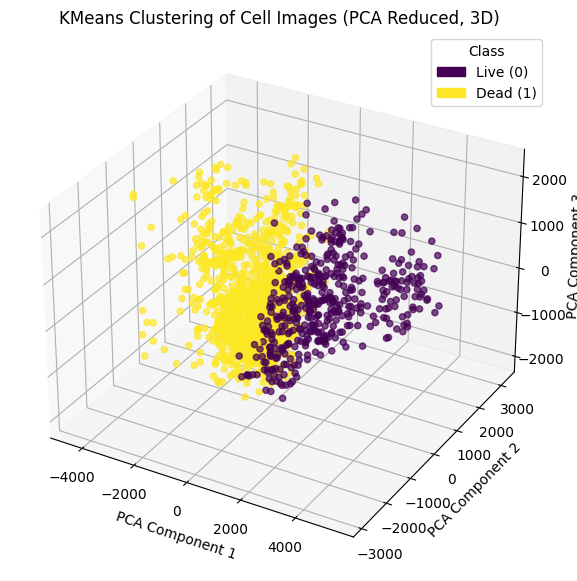

In [ ]:
# KMeans clustering using module helper + prediction
kmeans_pixels = fit_kmeans(X_train_pca, n_clusters=2, seed=SEED)
y_pred = pca_kmeans_predict(X_train, pca_pixels, kmeans_pixels, invert_labels=True)

# Plot the clustered data in 3D (PC1, PC2, PC3)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], X_train_pca[:, 2], c=y_pred, cmap='viridis', alpha=0.7)
ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('KMeans Clustering of Cell Images (PCA Reduced, 3D)')

cmap = plt.cm.viridis
live_patch = mpl.patches.Patch(color=cmap(0.0), label='Live (0)')
dead_patch = mpl.patches.Patch(color=cmap(1.0), label='Dead (1)')
ax.legend(handles=[live_patch, dead_patch], title='Class', loc='best')
plt.show()

Timing section

In [ ]:
# Timing PCA fit_transform and KMeans clustering (k=2)
_t0 = time.time()
X_train_flat = X_train.reshape(X_train.shape[0], -1)
pca_timed = PCA(n_components=3)
X_train_pca_timed = pca_timed.fit_transform(X_train_flat)
pca_time_s = time.time() - _t0
print(f"PCA fit+transform time: {pca_time_s:.4f}s")

# Time KMeans clustering with k=2 on PCA features
_t1 = time.time()
kmeans_timed = KMeans(n_clusters=2, random_state=42)
kmeans_timed.fit(X_train_pca_timed)
kmeans_time_s = time.time() - _t1
print(f"KMeans (k=2) fit time: {kmeans_time_s:.4f}s")

# Keep references for later comparison (optional prediction)
y_pred_timed = kmeans_timed.labels_

PCA fit+transform time: 0.1122s
KMeans (k=2) fit time: 0.0342s


c:\Users\theod\miniconda3\envs\fys-stk4155\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [ ]:
# Use module prediction wrapper instead of defining locally
def pca_kmeans_model_pixels(X):
    return pca_kmeans_predict(X, pca_pixels, kmeans_pixels, invert_labels=True)

## F1 Score
The F1 score is the harmonic mean of precision and recall:
$$F_1 = 2 \cdot \frac{\text{precision} \cdot \text{recall}}{\text{precision} + \text{recall}}$$
with
$$\text{precision} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FP}}\quad\text{and}\quad\text{recall} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}}.$$
Here TP, FP, FN denote true positives, false positives, and false negatives.
We chose to use the F1 score because it gives a more vair evaluation metric when there is class imbalance like we see in our dataset. That is, we have more live cell examples than dead cell examples.

In [ ]:
# Calculate the accuracy and F1 score for the pca_kmeans_model on the training and the dev sets
y_train_pred = pca_kmeans_model_pixels(X_train)
y_dev_pred = pca_kmeans_model_pixels(X_dev)
train_accuracy = accuracy_score(y_train, y_train_pred)
dev_accuracy = accuracy_score(y_dev, y_dev_pred)

#Calculate the confusion matrix
dev_confusion_matrix_kmeans = confusion_matrix(y_dev, y_dev_pred)
print(f"Development Confusion Matrix: \n{dev_confusion_matrix_kmeans}")

# Calculate the ROC AUC scores
auc = roc_auc_score(y_train, y_train_pred)
print(f"Training AUC: {auc:.4f}")

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Development Accuracy: {dev_accuracy:.4f}")
train_f1 = f1_score(y_train, y_train_pred)
dev_f1 = f1_score(y_dev, y_dev_pred)
print(f"Training F1 Score: {train_f1:.4f}")
print(f"Development F1 Score: {dev_f1:.4f}")

# Alias for plotting later without recomputation
dev_f1_kmeans = dev_f1
dev_roc_auc_kmeans = auc
dev_accuracy_kmeans = dev_accuracy

Development Confusion Matrix: 
[[ 30 111]
 [ 18  34]]
Training AUC: 0.4615
Training Accuracy: 0.3704
Development Accuracy: 0.3316
Training F1 Score: 0.3601
Development F1 Score: 0.3452


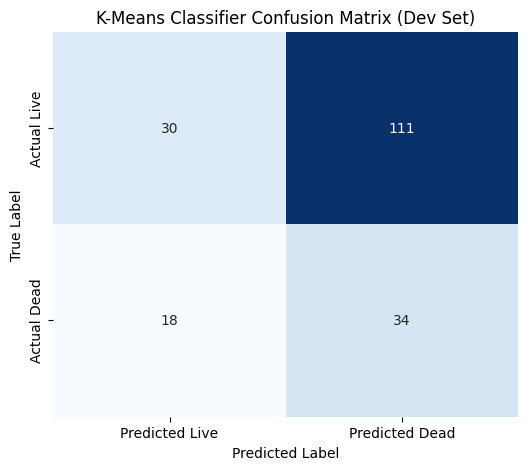

In [ ]:
# Plot the confusion matrix for the k-means model via module helper
plot_confusion(dev_confusion_matrix_kmeans, 'K-Means Classifier Confusion Matrix (Dev Set)')

## Feature engineering for unsupervised clustering

PCA and K-means on raw pixels fail to separate the classes.

Introducing hand-crafted features designed to capture biologically relevant cell structure.

In [ ]:
RUN_GRID_SEARCH = True
if RUN_GRID_SEARCH:

    param_grid = { #chose based on manual tuning and image inspection
        "n_components": [2, 3, 4, 5],
        "center_r": [2.5, 3.0, 3.5],
        "ring_r1": [3.5, 4.0, 4.5],
        "ring_r2": [7.0, 8.0, 9.0],
        "dark_thr": [0.25, 0.30, 0.35],
    }

    results = []

    for (n_comp, cr, r1, r2, dthr) in product(
        param_grid["n_components"],
        param_grid["center_r"],
        param_grid["ring_r1"],
        param_grid["ring_r2"],
        param_grid["dark_thr"],
    ):
        # Feature extraction
        F_train = extract_cell_features(
            X_train,
            center_r=cr,
            ring_r1=r1,
            ring_r2=r2,
            dark_thr=dthr,
        )
        F_dev = extract_cell_features(
            X_dev,
            center_r=cr,
            ring_r1=r1,
            ring_r2=r2,
            dark_thr=dthr,
        )

        # Standardize
        scaler = StandardScaler()
        F_train_s = scaler.fit_transform(F_train)
        F_dev_s = scaler.transform(F_dev)

        # PCA
        pca_feat = PCA(n_components=n_comp, random_state=SEED)
        Z_train = pca_feat.fit_transform(F_train_s)
        Z_dev = pca_feat.transform(F_dev_s)

        # KMeans
        kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=50)
        kmeans.fit(Z_train)

        preds = kmeans.predict(Z_dev)
        preds = best_flip(y_dev, preds)

        # Metrics
        f1 = f1_score(y_dev, preds)
        bal_acc = balanced_accuracy_score(y_dev, preds)

        results.append({
            "n_components": n_comp,
            "center_r": cr,
            "ring_r1": r1,
            "ring_r2": r2,
            "dark_thr": dthr,
            "f1": f1,
            "balanced_acc": bal_acc,
        })

    # Sort by F1 - more informative for imbalanced classes
    results = sorted(results, key=lambda x: x["f1"], reverse=True)

    for r in results[:5]:
        print(r)


{'n_components': 3, 'center_r': 2.5, 'ring_r1': 4.0, 'ring_r2': 7.0, 'dark_thr': 0.3, 'f1': 0.6754966887417218, 'balanced_acc': 0.8201718494271686}
{'n_components': 3, 'center_r': 2.5, 'ring_r1': 4.5, 'ring_r2': 7.0, 'dark_thr': 0.3, 'f1': 0.6710526315789475, 'balanced_acc': 0.8166257501363885}
{'n_components': 2, 'center_r': 2.5, 'ring_r1': 4.5, 'ring_r2': 7.0, 'dark_thr': 0.3, 'f1': 0.6666666666666666, 'balanced_acc': 0.8130796508456083}
{'n_components': 3, 'center_r': 2.5, 'ring_r1': 3.5, 'ring_r2': 8.0, 'dark_thr': 0.3, 'f1': 0.6666666666666666, 'balanced_acc': 0.8130796508456083}
{'n_components': 3, 'center_r': 2.5, 'ring_r1': 4.0, 'ring_r2': 8.0, 'dark_thr': 0.25, 'f1': 0.6666666666666666, 'balanced_acc': 0.8130796508456083}


In [ ]:
# Final selected parameters (chosen via dev-set sweep)
FINAL_PARAMS = dict(
    center_r=2.5,
    ring_r1=4.0,
    ring_r2=7.0,
    dark_thr=0.30,
)
n_components_final=3

Timing section

In [ ]:
_t0 = time.time()

F_train = extract_cell_features(X_train, **FINAL_PARAMS)
F_dev   = extract_cell_features(X_dev, **FINAL_PARAMS)

scaler = StandardScaler()
F_train_s = scaler.fit_transform(F_train)
F_dev_s   = scaler.transform(F_dev)

pca_feat = PCA(n_components=n_components_final, random_state=SEED)
Z_train = pca_feat.fit_transform(F_train_s)
Z_dev   = pca_feat.transform(F_dev_s)

kmeans = KMeans(n_clusters=2, random_state=SEED, n_init=50)
kmeans.fit(Z_train)

dev_labels_feat = best_flip(y_dev, kmeans.predict(Z_dev))

feature_pca_time_s = time.time() - _t0
print(f"Feature PCA + KMeans total time: {feature_pca_time_s:.4f}s")

Feature PCA + KMeans total time: 1.0626s


Feature PCA metrics

[[93 48]
 [ 1 51]]


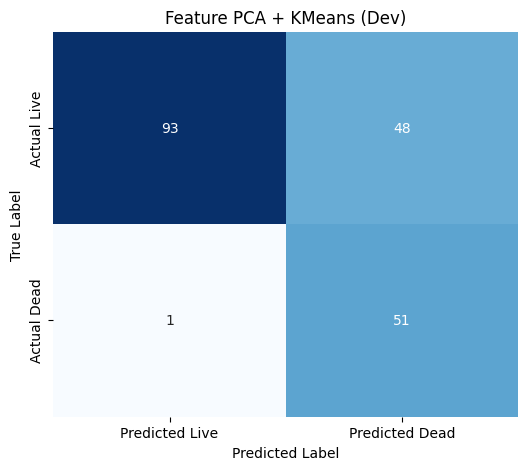

In [ ]:
# Feature-based KMeans metrics
dev_accuracy_feat_kmeans = accuracy_score(y_dev, dev_labels_feat)
dev_f1_feat_kmeans       = f1_score(y_dev, dev_labels_feat)
dev_bal_acc_feat_kmeans  = balanced_accuracy_score(y_dev, dev_labels_feat)
dev_roc_auc_feat_kmeans  = roc_auc_score(y_dev, dev_labels_feat)

dev_confusion_matrix_feat_kmeans = confusion_matrix(y_dev, dev_labels_feat)

print(dev_confusion_matrix_feat_kmeans)
plot_confusion(dev_confusion_matrix_feat_kmeans, "Feature PCA + KMeans (Dev)")

### Feature PCA variance sweep

In [ ]:
F_train_feat = extract_cell_features(X_train, **FINAL_PARAMS)

scaler_feat = StandardScaler()
F_train_feat_s = scaler_feat.fit_transform(F_train_feat)

components_feat = [1, 2, 3, 4, 5, 6, 8, 10]
explained_variances_feat = []

for m in components_feat:
    pca_feat_tmp = PCA(n_components=m, random_state=SEED)
    pca_feat_tmp.fit(F_train_feat_s)
    evr = pca_feat_tmp.explained_variance_ratio_.sum()
    explained_variances_feat.append(evr)
    print(f"Feature PCA | m={m:2d} | EVR={evr:.4f}")



Feature PCA | m= 1 | EVR=0.4801
Feature PCA | m= 2 | EVR=0.7208
Feature PCA | m= 3 | EVR=0.8651
Feature PCA | m= 4 | EVR=0.9264
Feature PCA | m= 5 | EVR=0.9661
Feature PCA | m= 6 | EVR=0.9793
Feature PCA | m= 8 | EVR=0.9961
Feature PCA | m=10 | EVR=0.9999


### PCA explainec varaince plot (all representations)

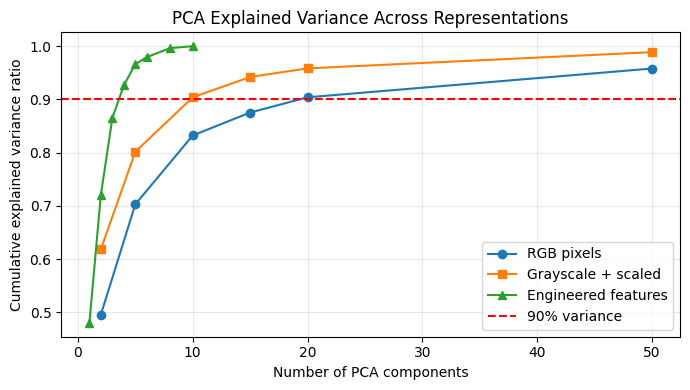

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(
    components,
    explained_variances,
    marker='o',
    label='RGB pixels'
)

plt.plot(
    components,
    explained_variances_v2,
    marker='s',
    label='Grayscale + scaled'
)

plt.plot(
    components_feat,
    explained_variances_feat,
    marker='^',
    label='Engineered features'
)

plt.axhline(
    0.90,
    color='red',
    linestyle='--',
    label='90% variance'
)

plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance ratio')
plt.title('PCA Explained Variance Across Representations')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Note: different PCA component grids used for pixel/feature representations.

Checking which features contribute the most to the variance, PCs

In [ ]:
feature_names = [
    "gmean","gstd","cmean","rmean","c_minus_r","c_over_r",
    "radial_std","edge_energy","lap_var","dark_frac",
    "center_p90","peak_over_ring"
]

F_train_feat = extract_cell_features(X_train) # unscaled
vars_ = F_train_feat.var(axis=0)

for name, v in sorted(zip(feature_names, vars_), key=lambda t: -t[1]):
    print(f"{name:12s} var={v:.3g}")

scaler_feat = StandardScaler()
F_train_feat_s = scaler_feat.fit_transform(F_train_feat)

pca_feat_analysis = PCA(n_components=7, random_state=42)
pca_feat_analysis.fit(F_train_feat_s)

evr_feat = pca_feat_analysis.explained_variance_ratio_
print("Explained var ratio per PC:", np.round(evr_feat, 3))
print("Cumulative EVR:", np.round(np.cumsum(evr_feat), 3))

for j in range(3):
    load = pca_feat_analysis.components_[j]
    idx = np.argsort(np.abs(load))[::-1][:3]
    print(f"\nPC{j+1}:")
    for k in idx:
        print(f"  {feature_names[k]:12s} loading={load[k]:+.3f}")


peak_over_ring var=0.109
c_over_r     var=0.0919
center_p90   var=0.0625
cmean        var=0.0589
rmean        var=0.0332
dark_frac    var=0.0315
c_minus_r    var=0.0201
gmean        var=0.0102
radial_std   var=0.00445
gstd         var=0.0031
edge_energy  var=0.0012
lap_var      var=4.94e-06
Explained var ratio per PC: [0.482 0.238 0.146 0.061 0.04  0.013 0.011]
Cumulative EVR: [0.482 0.72  0.866 0.927 0.966 0.98  0.991]

PC1:
  c_minus_r    loading=+0.370
  edge_energy  loading=+0.360
  radial_std   loading=+0.337

PC2:
  rmean        loading=+0.530
  gmean        loading=+0.472
  dark_frac    loading=-0.349

PC3:
  lap_var      loading=+0.476
  gstd         loading=+0.374
  c_over_r     loading=-0.329


## Visualization

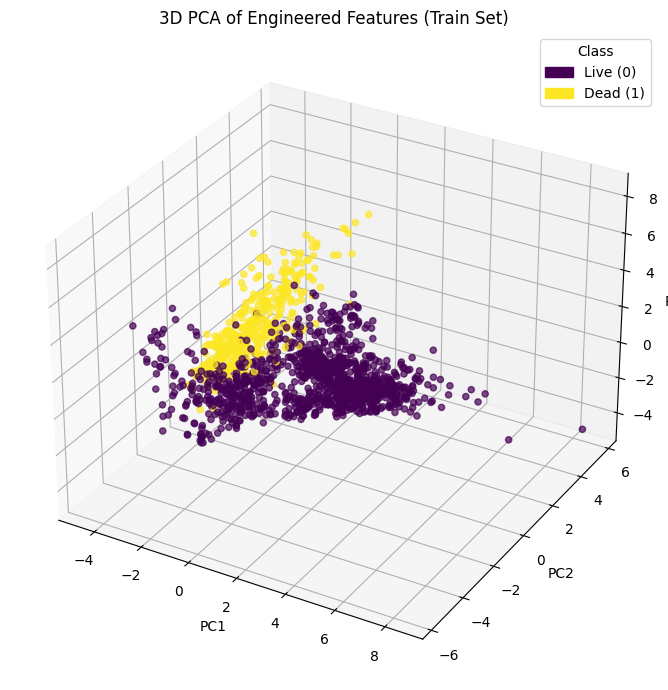

In [ ]:
# 3D plot of FEATURE PCA components (colored by true labels)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    Z_train[:, 0], Z_train[:, 1], Z_train[:, 2],
    c=y_train, cmap='viridis', alpha=0.7
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D PCA of Engineered Features (Train Set)')

cmap = plt.cm.viridis
live_patch = mpl.patches.Patch(color=cmap(0.0), label='Live (0)')
dead_patch = mpl.patches.Patch(color=cmap(1.0), label='Dead (1)')
ax.legend(handles=[live_patch, dead_patch], title='Class', loc='best')

plt.tight_layout()
plt.show()


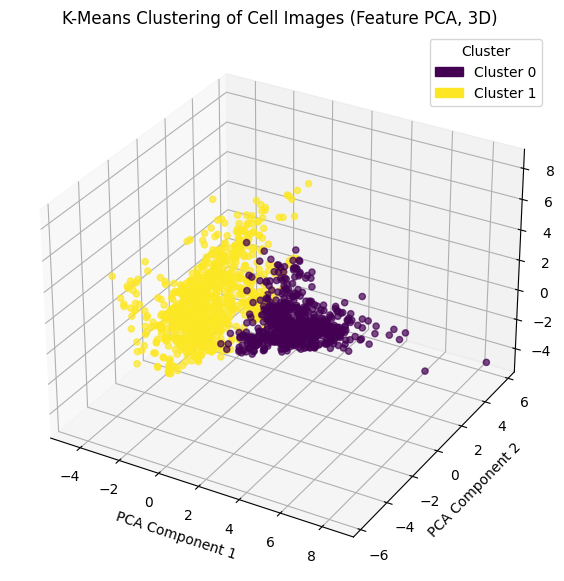

In [ ]:
# Predict clusters in FEATURE PCA space
cluster_labels = kmeans.predict(Z_train)

# Plot the clustered FEATURE PCA data in 3D (PC1, PC2, PC3)
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    Z_train[:, 0],
    Z_train[:, 1],
    Z_train[:, 2],
    c=cluster_labels,
    cmap='viridis',
    alpha=0.7
)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('PCA Component 3')
ax.set_title('K-Means Clustering of Cell Images (Feature PCA, 3D)')

# Legend matching the pixel-based figure style
cmap = plt.cm.viridis
cluster0 = mpl.patches.Patch(color=cmap(0.0), label='Cluster 0')
cluster1 = mpl.patches.Patch(color=cmap(1.0), label='Cluster 1')
ax.legend(handles=[cluster0, cluster1], title='Cluster', loc='best')

plt.show()


# MLP on PCA embedding space

## Neural Network Architecture (MLPClassifier)

**Layer 1 - Input Layer**
- Size: *PCA feature dimension*  
- Receives standardized PCA features.

**Layer 2 - Hidden Layer 1**
- 64 neurons  
- Activation: **ReLU**  
- Regularization: **L2 weight decay** (alpha = 1e-4)

**Layer 3 - Hidden Layer 2**
- 64 neurons  
- Activation: **ReLU**  
- Regularization: **L2 weight decay** (alpha = 1e-4)

**Layer 4 - Output Layer**
- Size: number of classes (`len(np.unique(y_train))`)  
- Activation: **Softmax** (handled internally)


## Training Details
- Optimizer: **Adam** 
- Loss Function: **Cross-entropy**  
- Max Iterations: **300**  
- Batch Size: **200** (sklearn default)  
- Regularization: **L2**, alpha = 1e-4  
- Random Seed: **42**


In [ ]:
## Scikit-learn MLP on Pixel PCA features

# Always derive features from the currently fitted `pca`
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_dev_flat   = X_dev.reshape(X_dev.shape[0], -1)
X_train_pca_cur = pca_pixels.transform(X_train_flat)
X_dev_pca_cur   = pca_pixels.transform(X_dev_flat)
print("Feature dims - train:", X_train_pca_cur.shape[1], "dev:", X_dev_pca_cur.shape[1])

mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation="relu",
        max_iter=300,
        alpha=1e-4,
        random_state=42
    ))
])

# Measure training time
_t0 = time.time()
mlp_pipe.fit(X_train_pca_cur, y_train)
train_time = time.time() - _t0
mlp_train_time_s = train_time

# Epoch info from sklearn estimator
epochs_used = getattr(mlp_pipe.named_steps["mlp"], "n_iter_", None)
if epochs_used is not None and epochs_used > 0:
    avg_time_per_epoch = train_time / epochs_used
    print(f"Training time: {train_time:.2f}s | Avg per epoch: {avg_time_per_epoch:.4f}s over {epochs_used} epochs")
else:
    print(f"Training time: {train_time:.2f}s (epoch count unavailable)")

Feature dims - train: 3 dev: 3
Training time: 7.70s | Avg per epoch: 0.0286s over 269 epochs


In [ ]:
# Predictions
y_train_hat = mlp_pipe.predict(X_train_pca_cur)
y_dev_hat   = mlp_pipe.predict(X_dev_pca_cur)

train_mlp_accuracy = accuracy_score(y_train, y_train_hat)
dev_mlp_accuracy   = accuracy_score(y_dev, y_dev_hat)
train_mlp_f1 = f1_score(y_train, y_train_hat)
dev_mlp_f1   = f1_score(y_dev, y_dev_hat)

print(f"MLP (PCA) - Train Acc: {train_mlp_accuracy:.4f} | Dev Acc: {dev_mlp_accuracy:.4f}")
print(f"MLP (PCA) - Train F1:  {train_mlp_f1:.4f} | Dev F1:  {dev_mlp_f1:.4f}")

# Calculate the ROC AUC scores for the MLP model
mlp_dev_auc = roc_auc_score(y_dev, y_dev_hat)
print(f"MLP (PCA) - Dev AUC: {mlp_dev_auc:.4f}")

# Calculate the confusion matrix for the MLP model
mlp_dev_confusion_matrix = confusion_matrix(y_dev, y_dev_hat)
print(f"MLP (PCA) - Dev Confusion Matrix: \n{mlp_dev_confusion_matrix}")

MLP (PCA) - Train Acc: 0.8791 | Dev Acc: 0.8808
MLP (PCA) - Train F1:  0.7733 | Dev F1:  0.7677
MLP (PCA) - Dev AUC: 0.8335
MLP (PCA) - Dev Confusion Matrix: 
[[132   9]
 [ 14  38]]


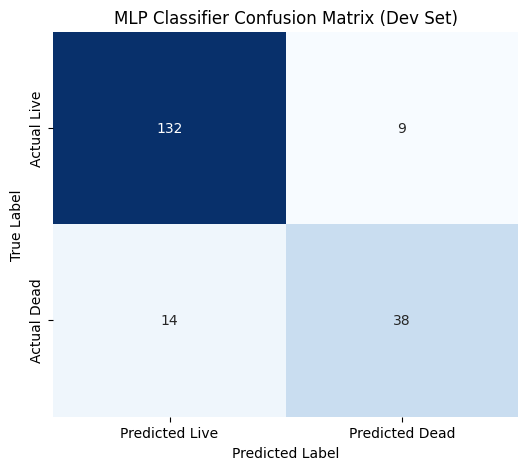

In [ ]:
# Plot the confusion matrix for the MLP model via module helper
plot_confusion(mlp_dev_confusion_matrix, 'MLP Classifier Confusion Matrix (Dev Set)')

# MLP on extracted features PCA space

### Hyperparameter sweep for MLP on feature engineered PCA space
Lets test some different hyperparameters for this MLP classifier. Starting with regularization term and the hidden dimensions.


MLP with hidden layers (2, 2) and alpha=1e-05


c:\Users\theod\miniconda3\envs\fys-stk4155\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



MLP with hidden layers (4, 4) and alpha=1e-05

MLP with hidden layers (8, 8) and alpha=1e-05

MLP with hidden layers (16, 16) and alpha=1e-05


c:\Users\theod\miniconda3\envs\fys-stk4155\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



MLP with hidden layers (32, 32) and alpha=1e-05

MLP with hidden layers (64, 64) and alpha=1e-05

MLP with hidden layers (2, 2) and alpha=0.0001


...


MLP with hidden layers (32, 32) and alpha=0.1

MLP with hidden layers (64, 64) and alpha=0.1

MLP with hidden layers (2, 2) and alpha=1.0

MLP with hidden layers (4, 4) and alpha=1.0


c:\Users\theod\miniconda3\envs\fys-stk4155\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



MLP with hidden layers (8, 8) and alpha=1.0

MLP with hidden layers (16, 16) and alpha=1.0


c:\Users\theod\miniconda3\envs\fys-stk4155\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



MLP with hidden layers (32, 32) and alpha=1.0

MLP with hidden layers (64, 64) and alpha=1.0

MLP with hidden layers (2, 2) and alpha=10.0

MLP with hidden layers (4, 4) and alpha=10.0

MLP with hidden layers (8, 8) and alpha=10.0

MLP with hidden layers (16, 16) and alpha=10.0

MLP with hidden layers (32, 32) and alpha=10.0

MLP with hidden layers (64, 64) and alpha=10.0

Best MLP configuration:
{'alpha': 1.0, 'hidden_layers': (64, 64), 'dev_f1': 0.830188679245283, 'dev_acc': 0.9067357512953368}


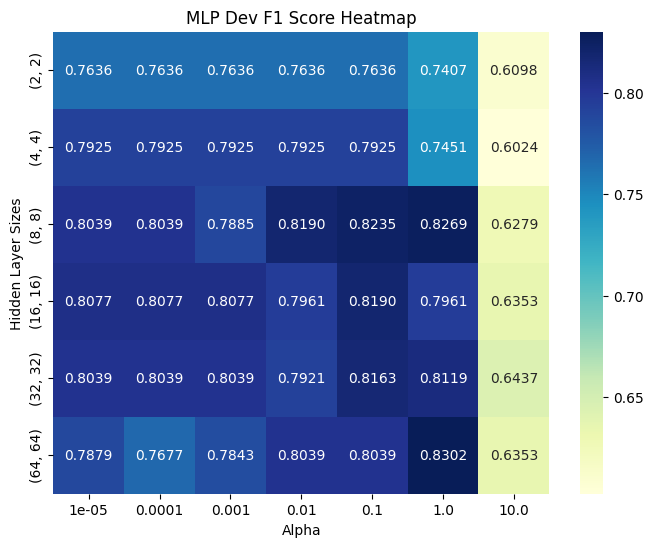

In [ ]:
alpha_vals = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1e0, 1e1]
hidden_layer_sizes = [(2,2), (4,4), (8,8), (16,16), (32, 32), (64, 64)]

results = []

for alpha in alpha_vals:
    for hls in hidden_layer_sizes:
        print(f"\nMLP with hidden layers {hls} and alpha={alpha}")
        mlp_pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPClassifier(
                hidden_layer_sizes=hls,
                activation="relu",
                max_iter=300,
                alpha=alpha,
                random_state=SEED
            ))
        ])
        mlp_pipe.fit(X_train_pca_cur, y_train)
        y_dev_hat = mlp_pipe.predict(X_dev_pca_cur)
        dev_f1 = f1_score(y_dev, y_dev_hat)
        dev_acc = accuracy_score(y_dev, y_dev_hat)
        
        # print(f"Alpha={alpha}, Hidden Layers={hls} | Dev F1: {dev_f1:.4f}, Dev Acc: {dev_acc:.4f}")
        results.append({
            "alpha": alpha,
            "hidden_layers": hls,
            "dev_f1": dev_f1,
            "dev_acc": dev_acc,
        })

# Find the model with the highest dev F1 score and the lowest hidden layers and highest alpha
best_result = max(results, key=lambda x: (x["dev_f1"], -sum(x["hidden_layers"]), x["alpha"]))
print("\nBest MLP configuration:")
print(best_result)

# Plot a heatmap comparing dev F1 scores for different alphas and hidden layer sizes
heatmap_data = pd.DataFrame(index=[str(hls) for hls in hidden_layer_sizes], columns=alpha_vals)
for res in results:
    heatmap_data.at[str(res["hidden_layers"]), res["alpha"]] = res["dev_f1"]
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data.astype(float), annot=True, fmt=".4f", cmap="YlGnBu")
plt.title("MLP Dev F1 Score Heatmap")
plt.xlabel("Alpha")
plt.ylabel("Hidden Layer Sizes")
plt.show()

### Conclusion form hyperparameter sweep
Many configurations produced the same maxinum F1 score. The tiebreaker was to then select for the model with the smallest capacity and highest regularization term.

Best MLP configuration:
{'alpha': 1.0, 'hidden_layers': (64, 64), 'dev_f1': 0.830188679245283, 'dev_acc': 0.9067357512953368}

MLP (feature PCA) - Train Acc: 0.9664 | Dev Acc: 0.9534
MLP (feature PCA) - Train F1:  0.9382 | Dev F1:  0.9109


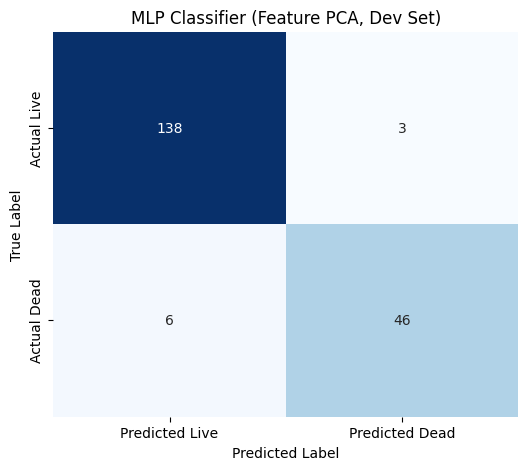

In [ ]:
# Reuse feature PCA outputs
X_train_pca_cur = Z_train
X_dev_pca_cur   = Z_dev

mlp_pipe = Pipeline([
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64, 64),
        activation="relu",
        max_iter=300,
        alpha=1.0,
        random_state=SEED
    ))
])

# Measure training time
_t0 = time.time()
mlp_pipe.fit(X_train_pca_cur, y_train)
feat_mlp_train_time_s = time.time() - _t0

# Predictions
y_train_hat = mlp_pipe.predict(X_train_pca_cur)
y_dev_hat   = mlp_pipe.predict(X_dev_pca_cur)

train_feat_mlp_accuracy = accuracy_score(y_train, y_train_hat)
dev_feat_mlp_accuracy   = accuracy_score(y_dev, y_dev_hat)
train_feat_mlp_f1 = f1_score(y_train, y_train_hat)
dev_feat_mlp_f1   = f1_score(y_dev, y_dev_hat)
dev_feat_mlp_auc = roc_auc_score(y_dev, y_dev_hat)

print(f"MLP (feature PCA) - Train Acc: {train_feat_mlp_accuracy:.4f} | Dev Acc: {dev_feat_mlp_accuracy:.4f}")
print(f"MLP (feature PCA) - Train F1:  {train_feat_mlp_f1:.4f} | Dev F1:  {dev_feat_mlp_f1:.4f}")

feat_mlp_dev_confusion_matrix = confusion_matrix(y_dev, y_dev_hat)
plot_confusion(feat_mlp_dev_confusion_matrix, "MLP Classifier (Feature PCA, Dev Set)")

# CNN on raw images

Now we will compare the unsupervised PCA + K-means approach to a well know image classification approach to supervised learning. We will implement a concolutional neural network using the pytorch library to classify the cell images as live or dead.

In [ ]:
print("Loaded shapes:", X_train.shape, X_dev.shape, X_test.shape)

Loaded shapes: (1547, 32, 32, 3) (193, 32, 32, 3) (194, 32, 32, 3)


In [ ]:
# Instantiate the model and move to device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=2).to(device)

# Show a short summary-like printout
num_params = sum(p.numel() for p in model.parameters())
print(model.__class__.__name__, f"on {device}")
print(f"Total parameters: {num_params}")

CNN on cpu
Total parameters: 38050


Lets explore the Dev accuracy as a function of batch size and learning rate.

Batch Size: 4, Learning Rate: 1e-05 => Dev Acc: 0.8705
Batch Size: 4, Learning Rate: 0.0001 => Dev Acc: 0.9948
Batch Size: 4, Learning Rate: 0.001 => Dev Acc: 1.0000
Batch Size: 4, Learning Rate: 0.01 => Dev Acc: 0.9793
Batch Size: 8, Learning Rate: 1e-05 => Dev Acc: 0.7306
Batch Size: 8, Learning Rate: 0.0001 => Dev Acc: 0.9948
Batch Size: 8, Learning Rate: 0.001 => Dev Acc: 0.9948
Batch Size: 8, Learning Rate: 0.01 => Dev Acc: 0.9845
Batch Size: 16, Learning Rate: 1e-05 => Dev Acc: 0.7306
Batch Size: 16, Learning Rate: 0.0001 => Dev Acc: 0.9741
Batch Size: 16, Learning Rate: 0.001 => Dev Acc: 1.0000
Batch Size: 16, Learning Rate: 0.01 => Dev Acc: 0.9845
Batch Size: 32, Learning Rate: 1e-05 => Dev Acc: 0.7306
Batch Size: 32, Learning Rate: 0.0001 => Dev Acc: 0.9482
Batch Size: 32, Learning Rate: 0.001 => Dev Acc: 0.9948
Batch Size: 32, Learning Rate: 0.01 => Dev Acc: 0.9896
Batch Size: 64, Learning Rate: 1e-05 => Dev Acc: 0.7306
Batch Size: 64, Learning Rate: 0.0001 => Dev Acc: 0.8964

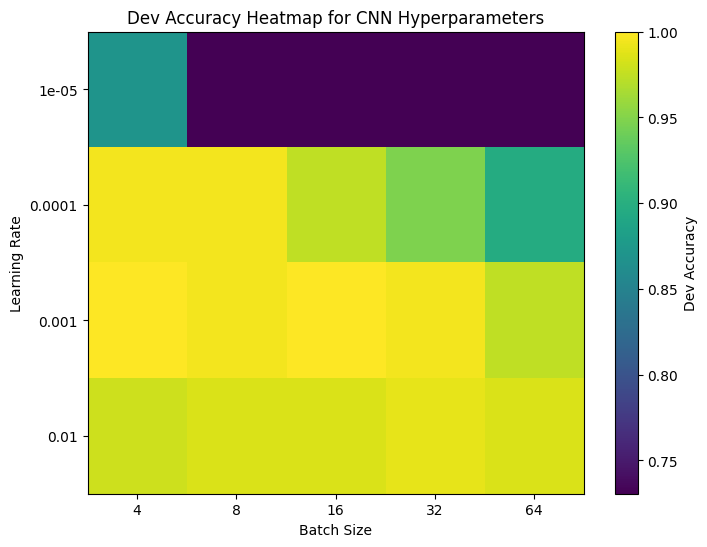

In [ ]:
PERFORM_TRAINING = True
if PERFORM_TRAINING:
    ## Hyperparameter search: seeded, re-init model per combo, correct heatmap

    # Use the global SEED defined earlier for reproducibility
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    batch_sizes = [4, 8, 16, 32, 64]
    learning_rates = [1e-5, 1e-4, 1e-3, 1e-2]
    results = []

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    for batch_size in batch_sizes:
        for lr in learning_rates:
            np.random.seed(SEED)
            torch.manual_seed(SEED)
            if torch.cuda.is_available():
                torch.cuda.manual_seed_all(SEED)

            generator = torch.Generator(device="cpu").manual_seed(SEED)

            model_grid = CNN(num_classes=2).to(device)
            train_loader, dev_loader = prepare_dataloaders(
                X_train, y_train, X_dev, y_dev, batch_size=batch_size
            )

            metrics = train_cnn(model_grid, train_loader, dev_loader, epochs=10, lr=lr, device=device)
            print(f"Batch Size: {batch_size}, Learning Rate: {lr} => Dev Acc: {metrics['last_dev_acc']:.4f}")
            results.append((batch_size, lr, metrics['last_dev_acc']))

    # Build a heatmap matrix with rows = learning_rates, cols = batch_sizes
    acc_grid = np.full((len(learning_rates), len(batch_sizes)), np.nan)
    bs_index = {bs: i for i, bs in enumerate(batch_sizes)}
    lr_index = {lr: j for j, lr in enumerate(learning_rates)}
    for bs, lr, acc in results:
        acc_grid[lr_index[lr], bs_index[bs]] = acc

    plt.figure(figsize=(8, 6))
    im = plt.imshow(acc_grid, cmap='viridis', aspect='auto')
    plt.colorbar(im, label='Dev Accuracy')
    plt.xticks(ticks=np.arange(len(batch_sizes)), labels=batch_sizes)
    plt.yticks(ticks=np.arange(len(learning_rates)), labels=learning_rates)
    plt.xlabel('Batch Size')
    plt.ylabel('Learning Rate')
    plt.title('Dev Accuracy Heatmap for CNN Hyperparameters')
    plt.show()

### Train the model using the best hyperparameters.
There was a two way tie for the best accuracy score, so I let the tiebreaker be the model with the largest batch size. This is because a larger batch size will reduce the training time needed to reach the same level of performance. 

In [ ]:
# Train the CNN model via module utilities

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

generator = torch.Generator(device="cpu").manual_seed(SEED)
model_best = CNN(num_classes=2).to(device)

train_loader, dev_loader = prepare_dataloaders(
    X_train, y_train, X_dev, y_dev, batch_size=16
)
metrics = train_cnn(model_best, train_loader, dev_loader, epochs=10, lr=0.001, device=device)
print(f"Total training time: {metrics['train_time_s']:.2f}s | Dev Acc: {metrics['last_dev_acc']:.4f}")
cnn_train_time_s = metrics['train_time_s']

Total training time: 8.47s | Dev Acc: 1.0000


## Loss Curves

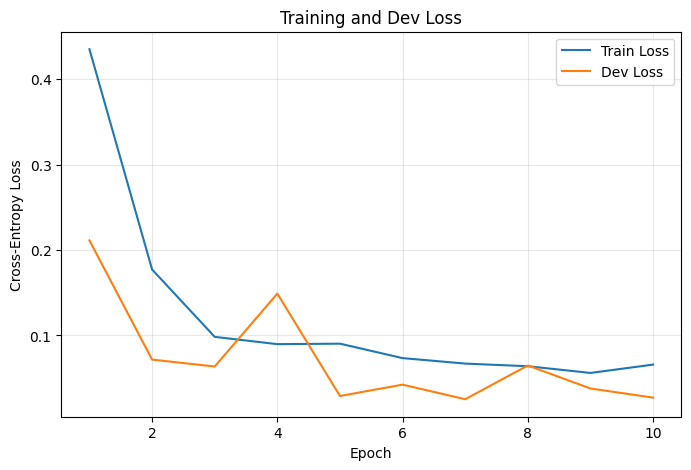

In [ ]:
# Plot training and dev loss curves

if len(metrics["train_losses"]) and len(metrics["dev_losses"]):
    epochs_range = list(range(1, len(metrics["train_losses"]) + 1))
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, metrics["train_losses"], label='Train Loss')
    plt.plot(epochs_range, metrics["dev_losses"]    , label='Dev Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.title('Training and Dev Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No recorded losses found. Run the training cell first.")

In [ ]:
# Evaluate F1 score on the dev set via module
m = eval_dev_metrics(model_best, dev_loader, device=device)
dev_f1 = m['f1']
print(f"Dev F1 score: {dev_f1:.4f}")
dev_f1_cnn = dev_f1
y_true, y_hat = None, None  # placeholders kept for downstream plots

Dev F1 score: 1.0000


In [ ]:
# Compute the ROC AUC score on the dev set via module
m = eval_dev_metrics(model_best, dev_loader, device=device)
dev_roc_auc_cnn = m['roc_auc']
print(f"Dev ROC AUC score: {dev_roc_auc_cnn:.4f}")

Dev ROC AUC score: 1.0000


CNN Dev Confusion Matrix: 
[[141   0]
 [  0  52]]


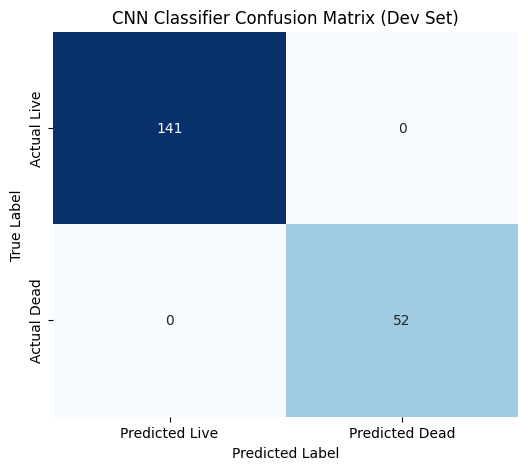

In [ ]:
# Confusion matrix for the CNN model via module
m = eval_dev_metrics(model_best, dev_loader, device=device)
cnn_dev_confusion_matrix = m['confusion']
print(f"CNN Dev Confusion Matrix: \n{cnn_dev_confusion_matrix}")
plot_confusion(cnn_dev_confusion_matrix, 'CNN Classifier Confusion Matrix (Dev Set)')

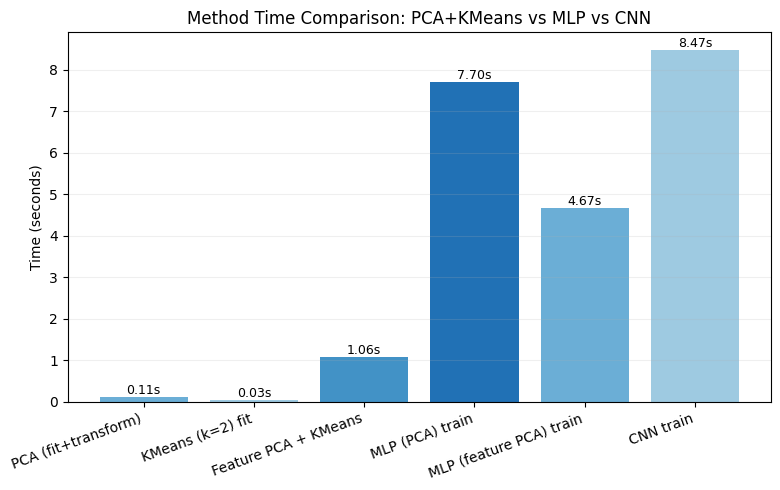

In [ ]:
# Compare processing/training times across methods

# ensure variables exist from earlier cells
times = {
    'PCA (fit+transform)': pca_time_s if 'pca_time_s' in globals() else np.nan,
    'KMeans (k=2) fit': kmeans_time_s if 'kmeans_time_s' in globals() else np.nan,
    'Feature PCA + KMeans': feature_pca_time_s if 'feature_pca_time_s' in globals() else np.nan,
    'MLP (PCA) train': mlp_train_time_s if 'mlp_train_time_s' in globals() else np.nan,
    'MLP (feature PCA) train': feat_mlp_train_time_s if 'feat_mlp_train_time_s' in globals() else np.nan,
    'CNN train': cnn_train_time_s if 'cnn_train_time_s' in globals() else np.nan,
}

labels = list(times.keys())
values = [times[k] for k in labels]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values, color=['#6baed6','#9ecae1','#4292c6','#2171b5'])
plt.ylabel('Time (seconds)')
plt.title('Method Time Comparison: PCA+KMeans vs MLP vs CNN')
plt.xticks(rotation=20, ha='right')
for bar, v in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{v:.2f}s" if not np.isnan(v) else "n/a",
             ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.grid(axis='y', alpha=0.2)
plt.show()

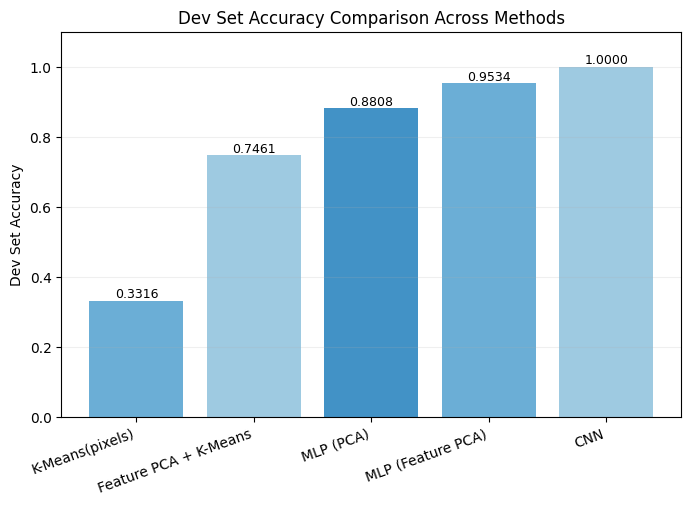

In [ ]:
# Compare the Dev Accuracy across methods
methods = ['K-Means(pixels)', 'Feature PCA + K-Means', 'MLP (PCA)', 'MLP (Feature PCA)', 'CNN']
accuracies = [dev_accuracy_kmeans, dev_accuracy_feat_kmeans, dev_mlp_accuracy, dev_feat_mlp_accuracy, metrics["dev_accs"][-1] if len(metrics["dev_accs"]) > 0 else np.nan]
plt.figure(figsize=(8, 5))
bars = plt.bar(methods, accuracies, color=['#6baed6','#9ecae1','#4292c6'])
plt.ylabel('Dev Set Accuracy')
plt.title('Dev Set Accuracy Comparison Across Methods')
plt.xticks(rotation=20, ha='right')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{acc:.4f}" if not np.isnan(acc) else "n/a",
             ha='center', va='bottom', fontsize=9)
plt.ylim(0, 1.1)
plt.grid(axis='y', alpha=0.2)
plt.show()

## F1 Score Comparison

We compare dev-set F1 scores for PCA+KMeans, MLP (on PCA features), and the CNN.

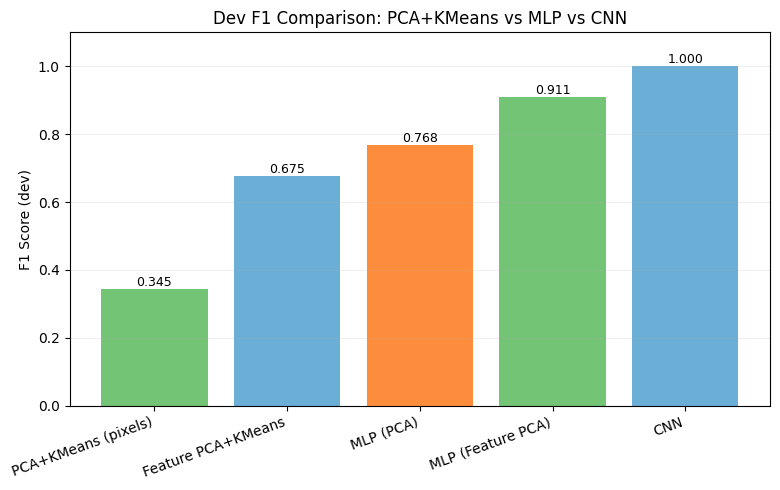

In [ ]:
## Bar plot of dev-set F1 scores for the three methods

# Fetch F1 scores
dev_f1_kmeans_val = dev_f1_kmeans if 'dev_f1_kmeans' in globals() else np.nan
dev_mlp_f1_val = dev_mlp_f1 if 'dev_mlp_f1' in globals() else np.nan
dev_f1_cnn_val = dev_f1_cnn if 'dev_f1_cnn' in globals() else (dev_f1 if 'dev_f1' in globals() else np.nan)

labels = ['PCA+KMeans (pixels)', 'Feature PCA+KMeans', 'MLP (PCA)', 'MLP (Feature PCA)', 'CNN']
values = [dev_f1_kmeans_val, dev_f1_feat_kmeans, dev_mlp_f1_val, dev_feat_mlp_f1, dev_f1_cnn_val]

plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=['#74c476', '#6baed6', '#fd8d3c'])
plt.ylim(0, 1.1)
plt.ylabel('F1 Score (dev)')
plt.title('Dev F1 Comparison: PCA+KMeans vs MLP vs CNN')
plt.xticks(rotation=20, ha='right')
for bar, v in zip(bars, values):
    height = 0 if np.isnan(v) else v
    label = 'n/a' if np.isnan(v) else f"{v:.3f}"
    plt.text(bar.get_x() + bar.get_width()/2, height, label, ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

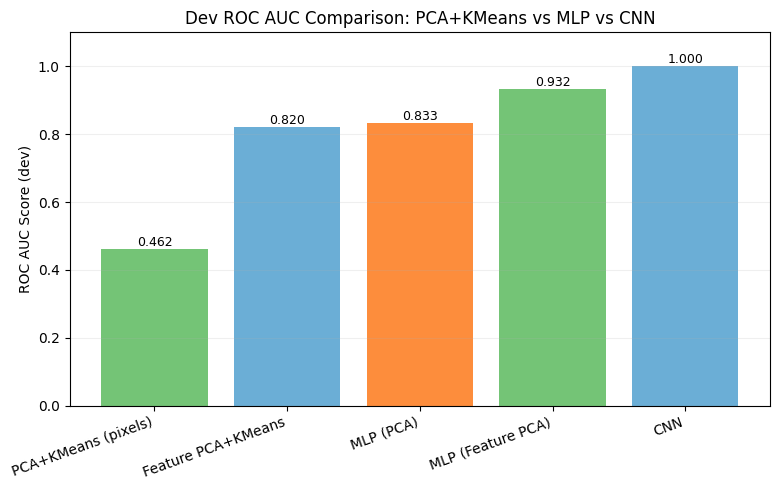

In [ ]:
# Compare the ROC AUC scores on the dev set for the three methods

dev_roc_auc_kmeans_val = dev_roc_auc_kmeans if 'dev_roc_auc_kmeans' in globals() else np.nan
dev_mlp_auc_val = mlp_dev_auc if 'mlp_dev_auc' in globals() else np.nan
dev_roc_auc_cnn_val = dev_roc_auc_cnn if 'dev_roc_auc_cnn' in globals() else (dev_roc_auc_cnn if 'dev_roc_auc_cnn' in globals() else np.nan)
labels = ['PCA+KMeans (pixels)', 'Feature PCA+KMeans', 'MLP (PCA)', 'MLP (Feature PCA)', 'CNN']
values = [dev_roc_auc_kmeans_val, dev_roc_auc_feat_kmeans, dev_mlp_auc_val, dev_feat_mlp_auc, dev_roc_auc_cnn_val]
plt.figure(figsize=(8,5))
bars = plt.bar(labels, values, color=['#74c476', '#6baed6', '#fd8d3c'])
plt.ylim(0, 1.1)
plt.ylabel('ROC AUC Score (dev)')
plt.title('Dev ROC AUC Comparison: PCA+KMeans vs MLP vs CNN')
plt.xticks(rotation=20, ha='right')
for bar, v in zip(bars, values):
    height = 0 if np.isnan(v) else v
    label = 'n/a' if np.isnan(v) else f"{v:.3f}"
    plt.text(bar.get_x() + bar.get_width()/2, height, label, ha='center', va='bottom', fontsize=9)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()


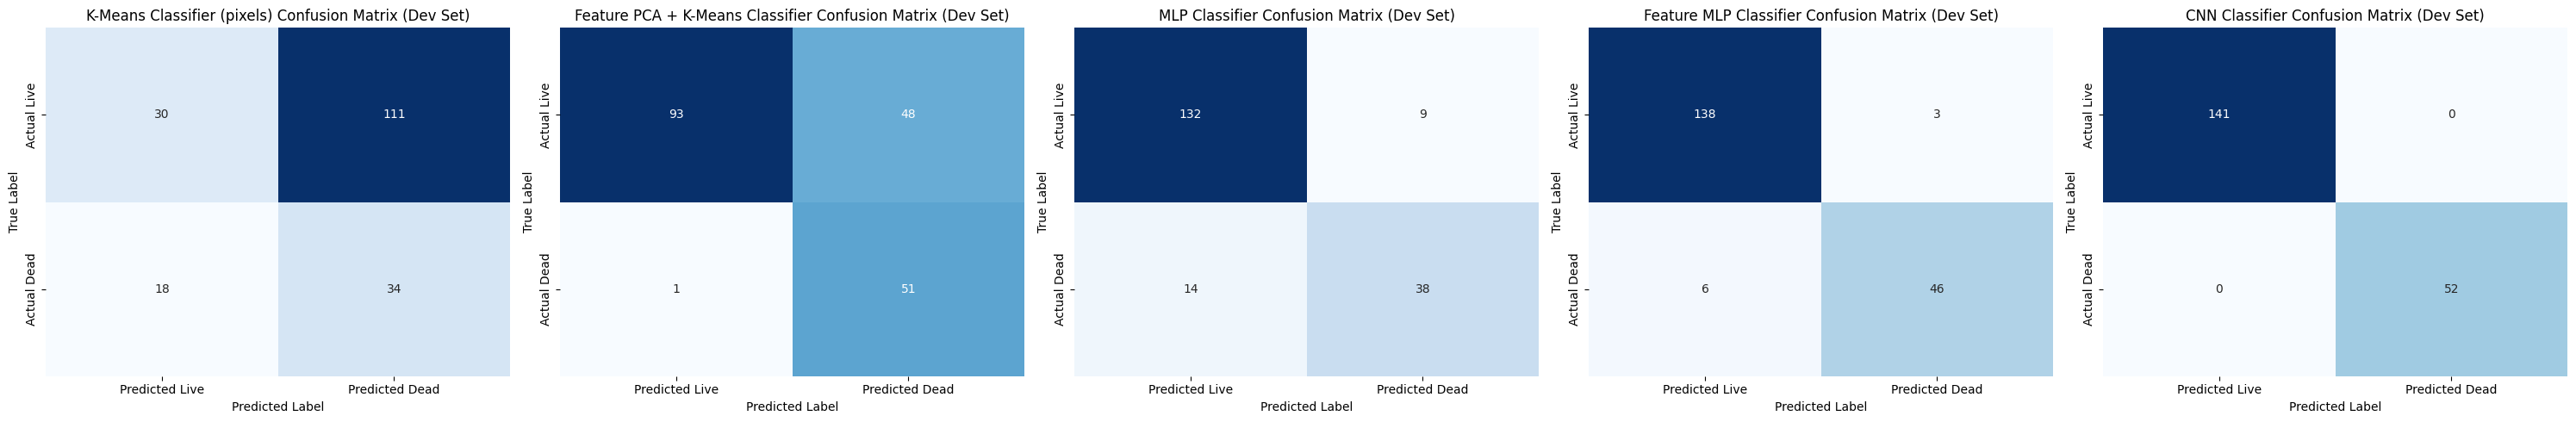

In [ ]:
# Display the three confusion matrices side by side using stored arrays
fig, axes = plt.subplots(1, 5, figsize=(30, 5))
conf_matrices = [
    (dev_confusion_matrix_kmeans, 'K-Means Classifier (pixels)'),
    (dev_confusion_matrix_feat_kmeans, 'Feature PCA + K-Means Classifier'),
    (mlp_dev_confusion_matrix, 'MLP Classifier'),
    (feat_mlp_dev_confusion_matrix, 'Feature MLP Classifier'),
    (cnn_dev_confusion_matrix, 'CNN Classifier')
 ]
for ax, (cm, title) in zip(axes, conf_matrices):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted Live', 'Predicted Dead'],
                yticklabels=['Actual Live', 'Actual Dead'], ax=ax)
    ax.set_title(f'{title} Confusion Matrix (Dev Set)')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')
plt.tight_layout()
plt.show()

# Test results
We test the model that performed the best on the validation (dev) sets. This follows the medical protocol for model selection. The holdout test set is designed to be only evaluated once the best model is selected. This reduces the possibility of picking the model with the best test performance and inadvertantly overfitting to the test set. This is especially true in cases where model performance is very close, but we follow it here in order to adhere to the protocol.

Test Acc: 0.9897
Test ROC AUC: 0.9930
Test Confusion Matrix:
[[140   2]
 [  0  52]]


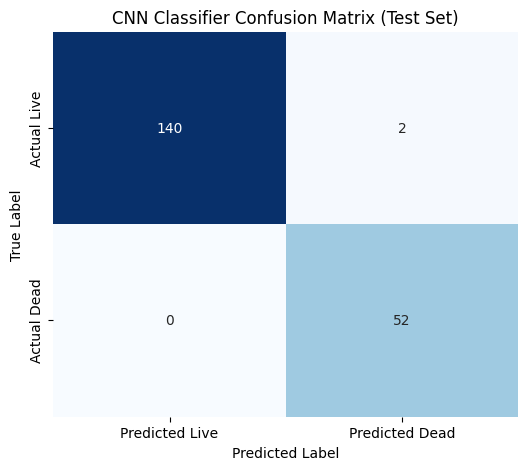

In [ ]:
## Plot accuracy, AUC, and confusion matrix for the CNN on the holdout test set

# Build test DataLoader (scale inputs to [0,1])
X_test_t = torch.tensor(X_test).permute(0, 3, 1, 2).float() / 255.0
y_test_t = torch.tensor(y_test).long()
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64, shuffle=False)

# Evaluate metrics on test set
m_test = eval_dev_metrics(model_best, test_loader, device=device)

cm = m_test['confusion']
# Accuracy from confusion matrix
test_acc = (cm[0,0] + cm[1,1]) / np.sum(cm)
test_auc = m_test['roc_auc']
print(f"Test Acc: {test_acc:.4f}")
print(f"Test ROC AUC: {test_auc:.4f}")
print(f"Test Confusion Matrix:\n{cm}")
plot_confusion(cm, 'CNN Classifier Confusion Matrix (Test Set)')